# 🌍 Limpieza y Normalización del Dataset de Partidos Internacionales

**Objetivo:** Este notebook se encarga de la limpieza, filtrado y normalización del dataset histórico de partidos internacionales de fútbol (`selecciones-partidos-completos.csv`). 

Este archivo contiene registros históricos de partidos disputados desde 1872. Para hacer que nuestras predicciones para el Mundial 2026 sean lo más precisas posibles, aplicaremos un pipeline de procesamiento de datos paso a paso en Python.

### 1. Importación de Librerías y Carga de Datos

En esta celda importamos `pandas` para el análisis tabular y `matplotlib` junto a `seaborn` para las visualizaciones gráficas. Cargamos el archivo CSV crudo con los partidos internacionales.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../datasets/raw/selecciones-partidos-completos.csv')
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


### 2. Exploración de Calidad del Dataset

Antes de aplicar cualquier cambio, debemos diagnosticar el estado actual de los datos. Definimos la función `reporte_calidad` para analizar la cantidad de registros, filas duplicadas, valores nulos (NaN) y tipos de columnas en el DataFrame.

In [2]:
def reporte_calidad(data):
    print(f'Shape: {data.shape}')
    print(f'Duplicados: {data.duplicated().sum()}')
    print('\nNulos por columna:')
    nulos = data.isnull().sum()
    pct_nulos = (data.isnull().sum() / len(data)) * 100
    df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct_nulos})
    print(df_nulos.round(2).to_string())
    print('\nTipos de datos:')
    print(data.dtypes)

reporte_calidad(df)

Shape: (49477, 9)
Duplicados: 0

Nulos por columna:
            Nulos  Porcentaje (%)
date            0            0.00
home_team       0            0.00
away_team       0            0.00
home_score     28            0.06
away_score     28            0.06
tournament      0            0.00
city            0            0.00
country         0            0.00
neutral         0            0.00

Tipos de datos:
date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
dtype: object


### 3. Visualización de Nulos y Distribución Temporal

Para entender mejor los datos de forma gráfica, generamos dos visualizaciones:
1. Un mapa de calor (heatmap) para ver dónde se concentran las celdas vacías.
2. Un histograma para analizar la frecuencia de partidos jugados a lo largo de la historia (años), demostrando que la mayor densidad de datos es reciente.

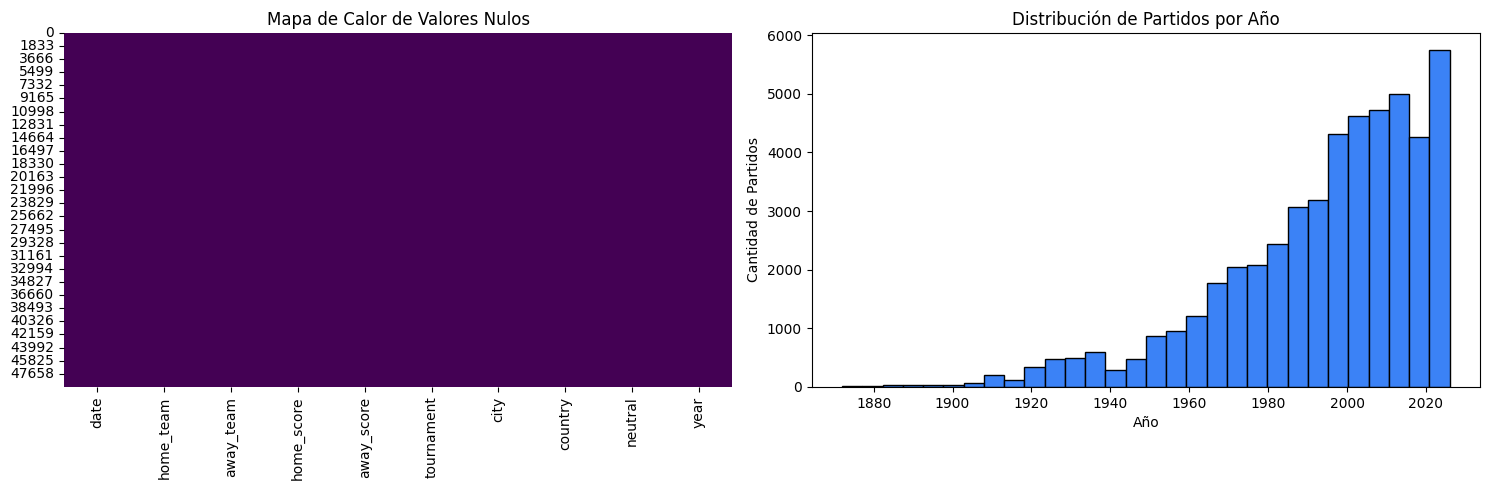

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap de nulos
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Mapa de Calor de Valores Nulos')

# Histograma temporal
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
axes[1].hist(df['year'].dropna(), bins=30, color='#3b82f6', edgecolor='black')
axes[1].set_title('Distribución de Partidos por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Cantidad de Partidos')

plt.tight_layout()
plt.show()

### 4. Filtrado por Año (Fútbol Moderno desde 2010)

El fútbol de épocas lejanas (como 1920 o 1950) responde a contextos tácticos y físicos muy distintos al actual, por lo que incluirlos perjudicaría las predicciones del Mundial 2026.

En esta celda, calculamos los partidos previos y posteriores a 2010, y filtramos el DataFrame para conservar únicamente los partidos jugados a partir del año 2010.

In [4]:
partidos_antes = (df['year'] < 2010).sum()
partidos_despues = (df['year'] >= 2010).sum()
print(f'Partidos antes de 2010: {partidos_antes}')
print(f'Partidos desde 2010: {partidos_despues}')

df_filtrado = df[df['year'] >= 2010].copy()
print(f'Nuevo tamaño del dataset: {df_filtrado.shape}')

Partidos antes de 2010: 33588
Partidos desde 2010: 15889
Nuevo tamaño del dataset: (15889, 10)


### 5. Tratamiento de Valores Nulos (NaN)

Los valores nulos en las columnas de marcadores (`home_score` y `away_score`) corresponden a partidos suspendidos, no disputados o cancelados.

Identificamos cuántas filas tienen marcadores vacíos, las eliminamos por completo mediante `dropna` y convertimos los resultados a números enteros (`int`).

In [5]:
nulos_antes = df_filtrado[['home_score', 'away_score']].isnull().any(axis=1).sum()
print(f'Filas con score nulo ANTES: {nulos_antes}')

df_filtrado.dropna(subset=['home_score', 'away_score'], inplace=True)
df_filtrado['home_score'] = df_filtrado['home_score'].astype(int)
df_filtrado['away_score'] = df_filtrado['away_score'].astype(int)

nulos_despues = df_filtrado[['home_score', 'away_score']].isnull().any(axis=1).sum()
print(f'Filas con score nulo DESPUÉS: {nulos_despues}')

Filas con score nulo ANTES: 28
Filas con score nulo DESPUÉS: 0


### 6. Normalización de Nombres de Selecciones

Para garantizar que los nombres de los equipos coincidan de forma idéntica con el dataset del fixture del Mundial 2026, creamos un diccionario de reemplazo. 

Esto normaliza discrepancias en nombres (por ejemplo, corregir 'United States' a 'USA', 'Korea Republic' a 'South Korea', etc.).

In [6]:
normalizacion = {
    'United States': 'USA',
    'IR Iran': 'Iran',
    'Korea Republic': 'South Korea',
    'Korea DPR': 'North Korea',
    'Côte d\'Ivoire': 'Ivory Coast',
    'DR Congo': 'DR Congo',
    'Bosnia and Herzegovina': 'Bosnia-Herzegovina',
    'Türkiye': 'Turkey',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'São Tomé and Príncipe': 'Sao Tome and Principe'
}

df_filtrado['home_team'] = df_filtrado['home_team'].replace(normalizacion)
df_filtrado['away_team'] = df_filtrado['away_team'].replace(normalizacion)
print("Normalización de nombres completada con éxito.")

Normalización de nombres completada con éxito.


### 7. Clasificación del Tipo de Torneo

El peso e intensidad competitiva de un partido amistoso es diferente al de una final del Mundial. 

Definimos una función llamada `clasificar_torneo` para mapear los distintos torneos en categorías estandarizadas: `mundial`, `eliminatoria`, `copa_continental` (Eurocopa, Copa América, etc.), `amistoso` u `otro`.

In [7]:
def clasificar_torneo(nombre):
    nombre = str(nombre).lower()
    if 'world cup' in nombre and 'qualifying' not in nombre:
        return 'mundial'
    elif 'qualifying' in nombre or 'eliminatorias' in nombre:
        return 'eliminatoria'
    elif any(x in nombre for x in ['copa america', 'euro', 'african cup', 'gold cup', 'asian cup', 'nations league', 'copa confederaciones']):
        return 'copa_continental'
    elif 'friendly' in nombre:
        return 'amistoso'
    else:
        return 'otro'

df_filtrado['tipo_torneo'] = df_filtrado['tournament'].apply(clasificar_torneo)
print(df_filtrado['tipo_torneo'].value_counts())

tipo_torneo
amistoso            5073
copa_continental    4508
mundial             3752
otro                2528
Name: count, dtype: int64


### 8. Eliminación de Columnas Irrelevantes y Filas Duplicadas

Para el modelo predictivo, la columna `city` (ciudad) no aporta valor explicativo. La eliminamos para optimizar el DataFrame.

Asimismo, verificamos si existen filas duplicadas en los registros y, si es así, las removemos y restablecemos el índice de filas.

In [8]:
# Eliminamos columnas innecesarias
df_filtrado.drop(columns=['city'], errors='ignore', inplace=True)

# Verificación y eliminación de duplicados
cant_duplicados = df_filtrado.duplicated().sum()
print(f'Duplicados encontrados: {cant_duplicados}')
if cant_duplicados > 0:
    df_filtrado.drop_duplicates(inplace=True)

df_filtrado.reset_index(drop=True, inplace=True)
print(f'Forma final del dataset: {df_filtrado.shape}')

Duplicados encontrados: 1
Forma final del dataset: (15860, 10)


### 9. Exportación del Dataset Limpio

Finalmente, guardamos los datos resultantes limpios en un nuevo archivo CSV denominado `partidos_internacionales_limpios.csv` dentro de la carpeta de datos procesados, para que pueda ser cargado de forma limpia por el notebook de entrenamiento de Machine Learning.

In [9]:
df_filtrado.to_csv('../datasets/processed/partidos_internacionales_limpios.csv', index=False)
print(f'Dataset exportado: {len(df_filtrado)} partidos')
print(f'Columnas finales: {list(df_filtrado.columns)}')
df_filtrado.head()

Dataset exportado: 15860 partidos
Columnas finales: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'country', 'neutral', 'year', 'tipo_torneo']


,date,home_team,away_team,home_score,away_score,tournament,country,neutral,year,tipo_torneo
0,2010-01-02,Iran,North Korea,1,0,Friendly,Qatar,True,2010,amistoso
1,2010-01-02,Qatar,Mali,0,0,Friendly,Qatar,False,2010,amistoso
2,2010-01-02,Syria,Zimbabwe,6,0,Friendly,Malaysia,True,2010,amistoso
3,2010-01-02,Yemen,Tajikistan,0,1,Friendly,Yemen,False,2010,amistoso
4,2010-01-03,Angola,Gambia,1,1,Friendly,Portugal,True,2010,amistoso
